## Figure 3 from formation channel paper 

below is the code that reproduces Figure 3,4,5, and a few others of the formation channel paper 


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 
from typing import Optional  # change Optional[str] to str | None when using higher versions of python3

%matplotlib inline

In [2]:
## data path
path_to_github_folder = "/Users/floorbroekgaarden/Projects/GitHub/"
path_to_file_folder = "Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/"
path_to_file = path_to_github_folder + path_to_file_folder


### Instructions 

for this code to work you will need the following files 
  - `DCOlabel + "_rates_review.csv"` For DCOlabel in BH-BH, BH-NS, and NS-NS  
 you can find this in the Zenodo file or on GitHub inside the Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/ folder 
  - it imports some functions from the `common_code` file above, but you dont need this :) (just uncomment if needed) 
  - likely you want to change the `save_path` in the code call below 
  

In [3]:


def obtain_fc_dict():
    """
    Returns a dictionary defining formation channel (fc) specifications.

    Each top-level key corresponds to a grouping of formation channels 
    (e.g., 'CE_simple', 'CE_detailed', or 'total').  
    Each group contains either a list of 'channels' (with properties) 
    or a single entry (for 'total').
    """


    palette = {
        # Neutrals
        "gray_light":  "#e0e0e0",
        "gray_dark":   "#C2C2C2",

        # Non-CE warm family
        "orange_main": "#FFA630",
        "orange_sub":  "#ffc857",
        "orange_soft": "#f4a259",
        "red_soft":    "#e45756",
        "rose":        "#d96c75",
        "terracotta":  "#bc4b51",
        "peach":       "#ffb5a7",

        # CE cool family
        "blue_main":   "#00A7E1",
        "blue_light":  "#5dade2",
        "blue_mid":    "#0474BA",
        "blue_dark":   "#004e89",
        "indigo":      "#3a3d98",   # new deep indigo for AIC
        "teal_light":  "#20b2aa",
        "green_blue":  "#58AD8B",
        "aqua":        "#00bfc4",
        "seafoam":     "#8dd3c7",
        "mint":        "#9de0ad",
    }


    fc_dict = {
        # A simplified common-envelope grouping (just two channels).
        "CE_simple": {
            "channels": [
                {"name": "fraction without common envelope", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope', "axlabel":"fraction without CE"},
                {"name": "fraction not specified",           "color":palette[ "gray_dark"],  "hatch":None,   "label":'other (CE not specified)'},
                {"name": "fraction with common envelope",    "color":palette["blue_main"],   "hatch": '//' , "label":'with common envelope', "axlabel":"fraction with CE"}
            ],
            "label_ncols":3
        },

        
        "CE_detailed": {
            "channels": [
                
                # --- Non-CE channels (warm hues, all unique) ---
                {"name": "without CE (no detail specified)", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope'},
                {"name": "SMT before and after channel",     "color":palette["red_soft"],    "hatch": '...', "label":'classic SMT (SMT + SMT)'},
                {"name": "SMT+NON",                          "color":palette["rose"],        "hatch": '...', "label":'SMT + NON'},
                {"name": "NON+SMT",                          "color":palette["orange_soft"], "hatch": '...', "label":'NON + SMT'},
                {"name": "NON + NON",                        "color":palette["terracotta"],  "hatch": '...', "label":'NON + NON'},
                {"name": "channel V intrinsic (z=0) other without CE", "color":palette["peach"], "hatch": 'ooo', "label":'other without CE'},
                {"name": "CHE",                              "color":palette["orange_sub"],     "hatch":'...',   "label":'CHE (no MT)'},
                
                
                {"name": "channel V intrinsic (z=0) CE not specified",    "color":palette["gray_dark"],  "hatch": None, "label":'other (CE not specified)'},
                
                # --- CE channels (cool hues, all unique) ---
                {"name": "with CE (no detail specified)",                 "color":palette["blue_main"],  "hatch": "//", "label":'with common envelope'},
                
                {"name": "channel I intrinsic (z=0) classic CE (SMT+CE)", "color":palette["blue_light"], "hatch": "//", "label":'classic CE'},
                {"name": "channel III intrinsic (z=0) SCCE",              "color":palette["blue_mid"],   "hatch": "\\", "label":'single-core CE'},
                {"name": "channel IV intrinsic (z=0) DCCE",               "color":palette["teal_light"], "hatch": '//', "label":'double-core CE'},
                
                {"name": "CEE + SMT",                                     "color":palette["green_blue"], "hatch": '//', "label":'CE + SMT'},
                {"name": "CEE+CEE",                                       "color":palette["aqua"],       "hatch": "\\", "label":'CE + CE'},
                {"name": "NON+CEE",                                       "color":palette["seafoam"],    "hatch": '//', "label":'NON + CE'},
                {"name": "CEE+NON",                                       "color":palette["mint"],       "hatch": '//', "label":'CE + NON'},

                {"name": "channel radCEE",  "color":palette["blue_dark"], "hatch": '\\', "label":'radiative CE'},
                {"name": "channel convCEE", "color":palette["teal_light"], "hatch": '//', "label":'convective CE'},
                {"name": "channel V intrinsic (z=0) other with CE", "color":palette["seafoam"], "hatch": "\\", "label":'other with CE'}
#                 {"name": "channel AIC with CE", "color":palette["indigo"], "hatch": '//', "label":'AIC with CE'},

            ],
            "label_ncols":5
        },

        # A total merger rate across all intrinsic channels.
        "total": {
            "name": "All intrinsic (z=0) [Gpc^-3 yr^-1]",
            "color": "black",
            "hatch": None,
            "label":r"All intrinsic ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]",
            "label_ncols":1,
            "axlabel":r"Total local merger rate", # % ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]
        },
    }

    return fc_dict


mpl.rcParams['hatch.linewidth'] = 0.5   # default is 1.0
mpl.rcParams['hatch.color'] = 'darkslategray'   # optional: set hatch color




def is_present(x):
    return (x is not None) and (not (isinstance(x, float) and pd.isna(x))) and (str(x).strip() != "")

def color_from_dict(d, key, default="0.7"):
    return d.get(key, default)


def draw_hlines(axe, v_values, list_h_values=[1E-3, 1E5]):
    """ draws lightgray custom vertical grid lines at values in the v_values list 
    these are drawn between the horizontal values given by list_h_values
    """
    for v_ in v_values:
        axe.plot(list_h_values, [v_, v_], lw=0.5, c='gray', ls=':', zorder=0)
        
    return 


def plot_observed_GWrate(axe, DCOlabel='BH-BH', lenmodels=10):
    # plot observed rates (make this a better function )
#     dict_rates_from_DCOlabel = {"BH-BH":[10.3, 61.0], "BH-NS":[8,  140.0], "NS-NS":[10.0, 1700.0]} # old rates 
    dict_rates_from_DCOlabel = {
        # rates from GWTC-4 POPulation paper 
        # "MERGED" [14, 26] rates from BBH column from Table 2 https://arxiv.org/pdf/2508.18083; includes +/-, 
        # but for BBH also adding the range from section 6.4 of the same paper  at z~0.2 which is POWER LAW REDSHIFT 29-6.5, 29+8.5, and for B-spline: 38-10 and 38+19, giving 
        # this gives total rate range of [14, 58]
        "BH-BH": [14, 58],
        # "MERGED" rates from BHNS column from Table 2 https://arxiv.org/pdf/2508.18083; includes +/- 
        "BH-NS": [9.1, 84],
          # "MERGED" rates from BNS column from Table 2 https://arxiv.org/pdf/2508.18083; includes +/- 
        "NS-NS": [7.6, 250]
    }
    
    min_obs_rate, max_obs_rate = dict_rates_from_DCOlabel[DCOlabel][0], dict_rates_from_DCOlabel[DCOlabel][1]
    axe.fill_betweenx(y=[-1, lenmodels], x1=[min_obs_rate,min_obs_rate], x2=[max_obs_rate,max_obs_rate], alpha=0.8, color='lightgray', zorder=1)
        

    return



def _load_and_sort_models(complete_path: str, sort_column: Optional[str]):
    """
    Load model data from CSV and sort by the given column.

    Returns
    -------
    df : pandas.DataFrame
        Sorted dataframe.
    models : pandas.Series
        Sorted list of models.
    """

    # Load model data
    df = pd.read_csv(complete_path)
    df = df.fillna(0.0)

    # Choose default sorting column if not provided
    if sort_column is None: df = df.sort_values(df.columns[0]).reset_index(drop=True)
    # Sort dataframe by chosen column
    else: df = df.sort_values(sort_column).reset_index(drop=True)

    return df, df['model']



def plot_total_rate(
    axe,
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = "fraction without common envelope",
    DCOlabel: str = 'BH-BH',
    fig_formtype: str = 'default'
    ):
    """
    Plot total gravitational-wave merger rates for different models.
    """
    
    fs_x2 = obtain_plotting_properties_dict(fig_formtype)["fs_x2"]
    
    fc_total_header = obtain_fc_dict()["total"]["name"]
    # Load and sort models
    df, models = _load_and_sort_models(complete_path, sort_column)

    # Plotting normalizer
    plot_size_normalizer = 1  

    # --- Plot total merger rates ---
    for ind_m, model in enumerate(models):
        total_rate = df[fc_total_header][ind_m]
        y_value    = ind_m / plot_size_normalizer  

        axe.scatter(
            total_rate,
            y_value,
            s=60,
            color=obtain_fc_dict()["total"]["color"],
            zorder=10,
            marker='d'
        )
        draw_hlines(axe=axe, v_values=[y_value])

    # --- Configure axes ---
    axe.set_ylim(-1, len(models) + 0.25)
    xlabel = r'$\mathcal{R}_{\rm{m}} \ [\rm{Gpc}^{-3} \rm{yr}^{-1}] $'
    layoutAxesNoYlabel(ax=axe, nameX=xlabel, nameY=False, noYticks=True, fontsize=18)

    axe.set_xscale('log')

    dictDCOlabel_xlim = {
        "BH-BH": [2, 600],
        "BH-NS": [0.2, 500],
        "NS-NS": [0.5, 2e3]  
    }
    axe.set_xlim(*dictDCOlabel_xlim[DCOlabel])

    # Add observed GW merger rates
    plot_observed_GWrate(axe, DCOlabel, len(models) + 0.25)

    return axe


def plot_formation_channels_rate(
    axe,
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = None,
    fc_coloring_option: str = "CE_simple",
    ):
    """
    Plot the contribution of different formation channels to the total merger rate.
    """
    # Get total header info
    fc_total_header = obtain_fc_dict()["total"]["name"]

    # Load and sort models
    df, models = _load_and_sort_models(complete_path, sort_column)

    # Plotting normalizer
    plot_size_normalizer = 1  
    
    
    # Filter channels so we only keep the ones present in df.columns (as the fc_dict is not BHBH, BHNS or BNS specific)
    valid_channels = [
        channel for channel in obtain_fc_dict()[fc_coloring_option]["channels"]
        if channel["name"] in df.columns
    ]
    
    # --- Plot channel contributions ---
    for ind_m, model in enumerate(models):
        total_rate = df[fc_total_header][ind_m]
        y_value    = ind_m / plot_size_normalizer  

        for channel in valid_channels:
            fc_name = channel["name"]
#             fc_hatch = channel["hatch"]
            channel_rate = df[fc_name].values[ind_m] * total_rate
#             color_c      = fc_channel_color_dict[channel]

            axe.scatter(
                channel_rate,
                y_value,
                s=50,
                edgecolor=channel["color"],
                facecolor='none',
                zorder=5,
                marker='s'
            )

    return axe



def obtain_models_colors(path_to_data='complete/path/to/simulation_specs.csv',
                         color_key="code_abbr",
                         cmap="husl"):
    """
    Creates a colormap dict for unique values in the provided CSV column.

    - Ignores missing values (NaN/None/empty) so you don't get a 'nan' category.
    - If color_key == 'label_1', also includes (optional) label_2 values, ignoring missing.
    """

    df = pd.read_csv(path_to_data)

    def _present_series(s: pd.Series) -> pd.Series:
        """Return cleaned series of present (non-empty, non-NaN) string values."""
        s = s.dropna()
        s = s.astype(str).str.strip()
        s = s[s != ""]
        return s

    # base column
    s = _present_series(df[color_key]) if color_key in df.columns else pd.Series([], dtype=str)

    # special: include label_2 categories too when building label_1 colormap
    if color_key == "label_1" and "label_2" in df.columns:
        s2 = _present_series(df["label_2"])
        s = pd.concat([s, s2], ignore_index=True)

    # unique category labels
    models = np.unique(s.values)

    # if nothing present, return empty dict
    if len(models) == 0:
        return {}

    colors = sns.color_palette(cmap, len(models))
    return dict(zip(models, colors))




def plot_simulation_properties(
    axe,
    specs_path: str = 'complete/path/to/simulation_specs.csv',
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = None,
    fig_formtype: str = 'default'
    #     fc_dict_key: str = "CE_simple"
    ):
    """
    Plot model simulation properties (e.g. author, code, stellar tracks) aligned with
    the merger rate plots.

    Parameters
    ----------
    axe : matplotlib.axes.Axes
        The matplotlib axis object on which to draw the plot.
    specs_path : str, optional
        Path to the CSV file containing model specifications (default: 'simulation_specs.csv').
    complete_path : str, optional
        Path to the CSV file containing the model rates (default: 'data.csv').
    sort_column : str or None, optional
        Column name by which to sort the models (default: None).
        If None, models are sorted by the first channel for the given fc_dict_key.
        If 'SMT', models are sorted by the sum of SMT-related channels.
    fc_dict_key : str, optional
        Key specifying which set of channels to use from fc_dict 
        (e.g., 'CE_simple', 'CE_detailed').
    fig_formtype 
        default or specs

    Returns
    -------
    axe : matplotlib.axes.Axes
        The matplotlib axis object with the plot drawn on it.
    """
    
    
    fs_x0 = obtain_plotting_properties_dict(fig_formtype)["fs_x0"]
    
    # --- Load and sort models by rates ---
    df_rates, models = _load_and_sort_models(complete_path, sort_column)


    # Special case: if None use the first header
    if sort_column is None:
        sort_column = fc_column_headers[0]
    df_rates = df_rates.sort_values(sort_column).reset_index(drop=True)

    # --- Load simulation specifications and align with sorted rates ---
    print('path', specs_path)
    df_specs = pd.read_csv(specs_path)
    df_specs = df_specs.set_index('model')
    df_specs = df_specs.reindex(index=df_rates['model']).reset_index()

    # --- Define color dictionaries for each property ---
    author_dict  = obtain_models_colors(specs_path, "label_author", "husl")
    code_dict    = obtain_models_colors(specs_path, "code", "husl")
    tracks_dict  = obtain_models_colors(specs_path, "stellar_tracks", "husl")
    labeli_dict  = obtain_models_colors(specs_path, "label_1", "husl")
    labelii_dict = obtain_models_colors(specs_path, "label_2", "husl")   
    
    # --- Plotting ---
    plot_size_normalizer = 1  
    xpositions = 0.02 + np.asarray([-0.2, 0, 0.3, 0.51, 0.8])  # x-offsets for each property column

    
    if fig_formtype=='emph_specs':
        labeliii_dict  = obtain_models_colors(specs_path, "label_3", "husl")
        labeliv_dict   = obtain_models_colors(specs_path, "label_4", "husl")     
        xpositions = 0.02 + np.asarray([-0.2, -0.05, 0.1, 0.25, 0.4, 0.55, 0.8])  # x-offsets for each property column
    

    
    
    for ind_m, model in enumerate(models):

        # ---- Required columns (fixed layout) ----
        label_author = df_specs["label_author"].iloc[ind_m]
        code         = df_specs["code"].iloc[ind_m]
        tracks       = df_specs["stellar_tracks"].iloc[ind_m]
        label1       = df_specs["label_1"].iloc[ind_m]

        # Optional var2, but keep a fixed slot for alignment
        label2 = df_specs["label_2"].iloc[ind_m]
        if not is_present(label2):
            label2_text  = ""               # blank text (nothing displayed)
            label2_color = (0, 0, 0, 0)      # transparent
        else:
            label2_text  = label2
            label2_color = color_from_dict(labelii_dict, label2_text, default="0.7")

        specs_labels = [label_author, code, tracks, label1, label2_text]

        colors_ = [
            color_from_dict(author_dict, label_author, default="0.7"),
            color_from_dict(code_dict, code, default="0.7"),
            color_from_dict(tracks_dict, tracks, default="0.7"),
            color_from_dict(labeli_dict, label1, default="0.7"),
            label2_color,
        ]

        # ---- Extra columns for emph_specs (also fixed slots) ----
        if fig_formtype == "emph_specs":
            label3 = df_specs["label_3"].iloc[ind_m]
            label4 = df_specs["label_4"].iloc[ind_m]

            if not is_present(label3):
                label3_text  = ""
                label3_color = (0, 0, 0, 0)
            else:
                label3_text  = label3
                label3_color = color_from_dict(labeliii_dict, label3_text, default="0.7")

            if not is_present(label4):
                label4_text  = ""
                label4_color = (0, 0, 0, 0)
            else:
                label4_text  = label4
                label4_color = color_from_dict(labeliv_dict, label4_text, default="0.7")

            specs_labels.extend([label3_text, label4_text])
            colors_.extend([label3_color, label4_color])

        y_value = ind_m / plot_size_normalizer

        # Place colored labels for each property (xpositions length stays constant)
        for ind_xpos, xpos in enumerate(xpositions):
            text = r'\textbf{%s}' % specs_labels[ind_xpos]
            axe.text(
                xpos, y_value,
                s=text,
                ha='left', va='center',
                fontsize=fs_x0,
                fontproperties='bold',
                color=colors_[ind_xpos]
            )

    
    
    #         draw_hlines(axe=axe, v_values=[y_value])

    # --- Add headers above columns ---
    labels = [
        r'$\textbf{name}$',
        r'$\textbf{code}$',
        r'$\textbf{tracks}$',
        r'$\textbf{parameters}$',
        r'$ $' 
#         r'$\textbf{paramet2}$'
    ]
    if fig_formtype=='emph_specs':
        labels = np.concatenate((labels, [r'$\textbf{var3}$', r'$\textbf{var4}$']))
    
    
    for ind_xpos, xpos in enumerate(xpositions):
        axe.text(
            xpos, y_value + 2,
            s=labels[ind_xpos],
            ha='left', va='top',
            fontsize=12
        )

    # --- Final formatting ---
    axe.set_ylim((-1, len(models) + 0.25))
    axe.set_xlim(0, 1)
    axe.axis('off')

    return axe



def obtain_plotting_properties_dict(fig_formtype='default'):
    
    fig_dim_dict = {'default':{"widths": [0.32, 1, 0.2],     "fs_x0":8,  "fs_x1":20, "fs_x2":20},
                    'emph_specs':{"widths": [1, 0.3, 0.2],  "fs_x0":8,  "fs_x1":8, "fs_x2":20}    
    }
    
    
    return fig_dim_dict[fig_formtype]
    
    

def plot_formation_channels_fraction(axe, complete_path='complete/path/to/data.csv', sort_column=None,
                                     fc_coloring_option="CE_simple", fig_formtype='default'):
    """
    Plot fractions of formation channels for each model in hbar (stacked).
    """

    # Load channel definitions from dictionary

    fc_total_header = obtain_fc_dict()["total"]["name"]
    fs_x1 = obtain_plotting_properties_dict(fig_formtype)["fs_x1"]
    
    df, models = _load_and_sort_models(complete_path, sort_column)
    
    
    # Plotting normalizer
    plot_size_normalizer = 1  

    # Filter channels so we only keep the ones present in df.columns (as the fc_dict is not BHBH, BHNS or BNS specific)
    valid_channels = [
        channel for channel in obtain_fc_dict()[fc_coloring_option]["channels"]
        if channel["name"] in df.columns
    ]
    
    # --- Plot channel contributions ---
    for ind_m, model in enumerate(models):
        total_rate, fc_fraction_low, fc_fraction_up  = df[fc_total_header][ind_m], 0, 0
        y_value    = ind_m / plot_size_normalizer  
        
        for channel in valid_channels:
            fc_name = channel["name"]
            fc_hatch = channel["hatch"]
            fc_fraction_up += df[fc_name].values[ind_m] 
            y_value = ind_m / plot_size_normalizer

            axe.barh(
                y_value, 
                fc_fraction_up - fc_fraction_low,  # width of this segment
                left=fc_fraction_low, 
                hatch=fc_hatch, 
                height=0.75, 
                color=channel["color"], 
                zorder=5
            )
            fc_fraction_low = fc_fraction_up

    # Formatting
    axe.set_ylim(-1, len(models)+0.25)
    axe.set_xlim(0, 1)
    axe.set_xticks(np.arange(0, 1.1, 0.1))
    layoutAxesNoYlabel(ax=axe, nameX=r'$\textbf{fraction}$', nameY=False, noYticks=True, setMinor=False, fontsize=fs_x1)
    axe.grid(True)

    return axe




def plot_formation_channel_contributions(
    path_to_file='/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/',
    DCOlabel='BH-NS',
    fc_key="CE_simple",
    sort_header="fraction without common envelope",
    show=True,
    save_path=None,
    fig_formtype='default'
    ):
    """
    Generate a three-panel figure summarizing population-synthesis predictions 
    for compact-object formation channel contributions.

    The function loads simulation results and creates:
        1. **Simulation properties panel (left):** displays metadata for each model 
           (e.g., simulation label, code, physics assumptions).
        2. **Formation channel fractions panel (middle):** stacked bar plot showing 
           the relative fractions of different formation channels (e.g., CE vs. non-CE).
        3. **Merger rates panel (right):** plots the total intrinsic merger rate 
           (z=0) along with contributions from individual formation channels.

    Parameters
    ----------
    path_to_file : str, optional
        Directory path containing the simulation results and specs CSV files.
    DCOlabel : str, optional
        Label for the double compact object type (e.g., 'BH-NS', 'BBH', 'NS-NS').
        Determines which `*_rates_review.csv` file is loaded.
    fc_key : str, optional
        Key selecting the formation channel coloring/labeling scheme from the 
        `fc_dict` (e.g., "CE_simple", "CE_detailed").
    sort_header : str, optional
        Column name (header) from the CSV file by which the models are sorted.
    show : bool, optional
        If True (default), displays the figure with `plt.show()`. 
        If False, returns the figure and axes without displaying.
    save_path : str or None, optional
        If provided, saves the figure to this path as a PDF.
    fig_formtype='default'
        type of plotting format, options: 'default', 'emph_specs'

    Returns
    -------
    f : matplotlib.figure.Figure
        The full matplotlib figure object.
    axe : list of matplotlib.axes.Axes
        List of axes objects corresponding to the three subplots.
    """

    # file location settings 
    file_name = DCOlabel + '_rates_review.csv'
    csv_path = path_to_file + file_name
    specs_path = path_to_file + 'simulation_specs.csv'

    # Figure dimensions
    w1, w2, w3 =obtain_plotting_properties_dict(fig_formtype)["widths"]
    d1, d2, w_small = 15, 12, 0.2
    
    
    if DCOlabel == 'BH-BH':
        d2=17
    
    ncols, nrows = 3, 1
    
    f, axe = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        figsize=(d1, d2),
        gridspec_kw={"width_ratios":[w1, w2, w3], "height_ratios":[1]}
    )

    # --- Plot 1: Simulation properties ---
    axe[0] = plot_simulation_properties(
        axe=axe[0],
        specs_path=specs_path,
        complete_path=csv_path,
        sort_column=sort_header,
        fig_formtype=fig_formtype
    )

    # --- Plot 2: Formation channels fraction ---
    axe[1] = plot_formation_channels_fraction(
        axe=axe[1],
        complete_path=csv_path,
        sort_column=sort_header,
        fc_coloring_option=fc_key,
        fig_formtype=fig_formtype
    )

    # --- Plot 3a: Total merger rate ---
    axe[2] = plot_total_rate(
        axe=axe[2],
        complete_path=csv_path,
        DCOlabel=DCOlabel,
        sort_column=sort_header,
        fig_formtype=fig_formtype
    )

    # --- Plot 3b: Formation channel contributions on same axis ---
    axe[2] = plot_formation_channels_rate(
        axe=axe[2],
        complete_path=csv_path,
        fc_coloring_option=fc_key,
        sort_column=sort_header
    )

    # --- Layout adjustments ---
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.0)

    # Save figure if path provided
    if save_path is not None:
        f.savefig(save_path, format='pdf', bbox_inches='tight')
    
    # Show the figure if requested
    if show:
        plt.show()

    return f, axe





# BH-BH mergers 

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


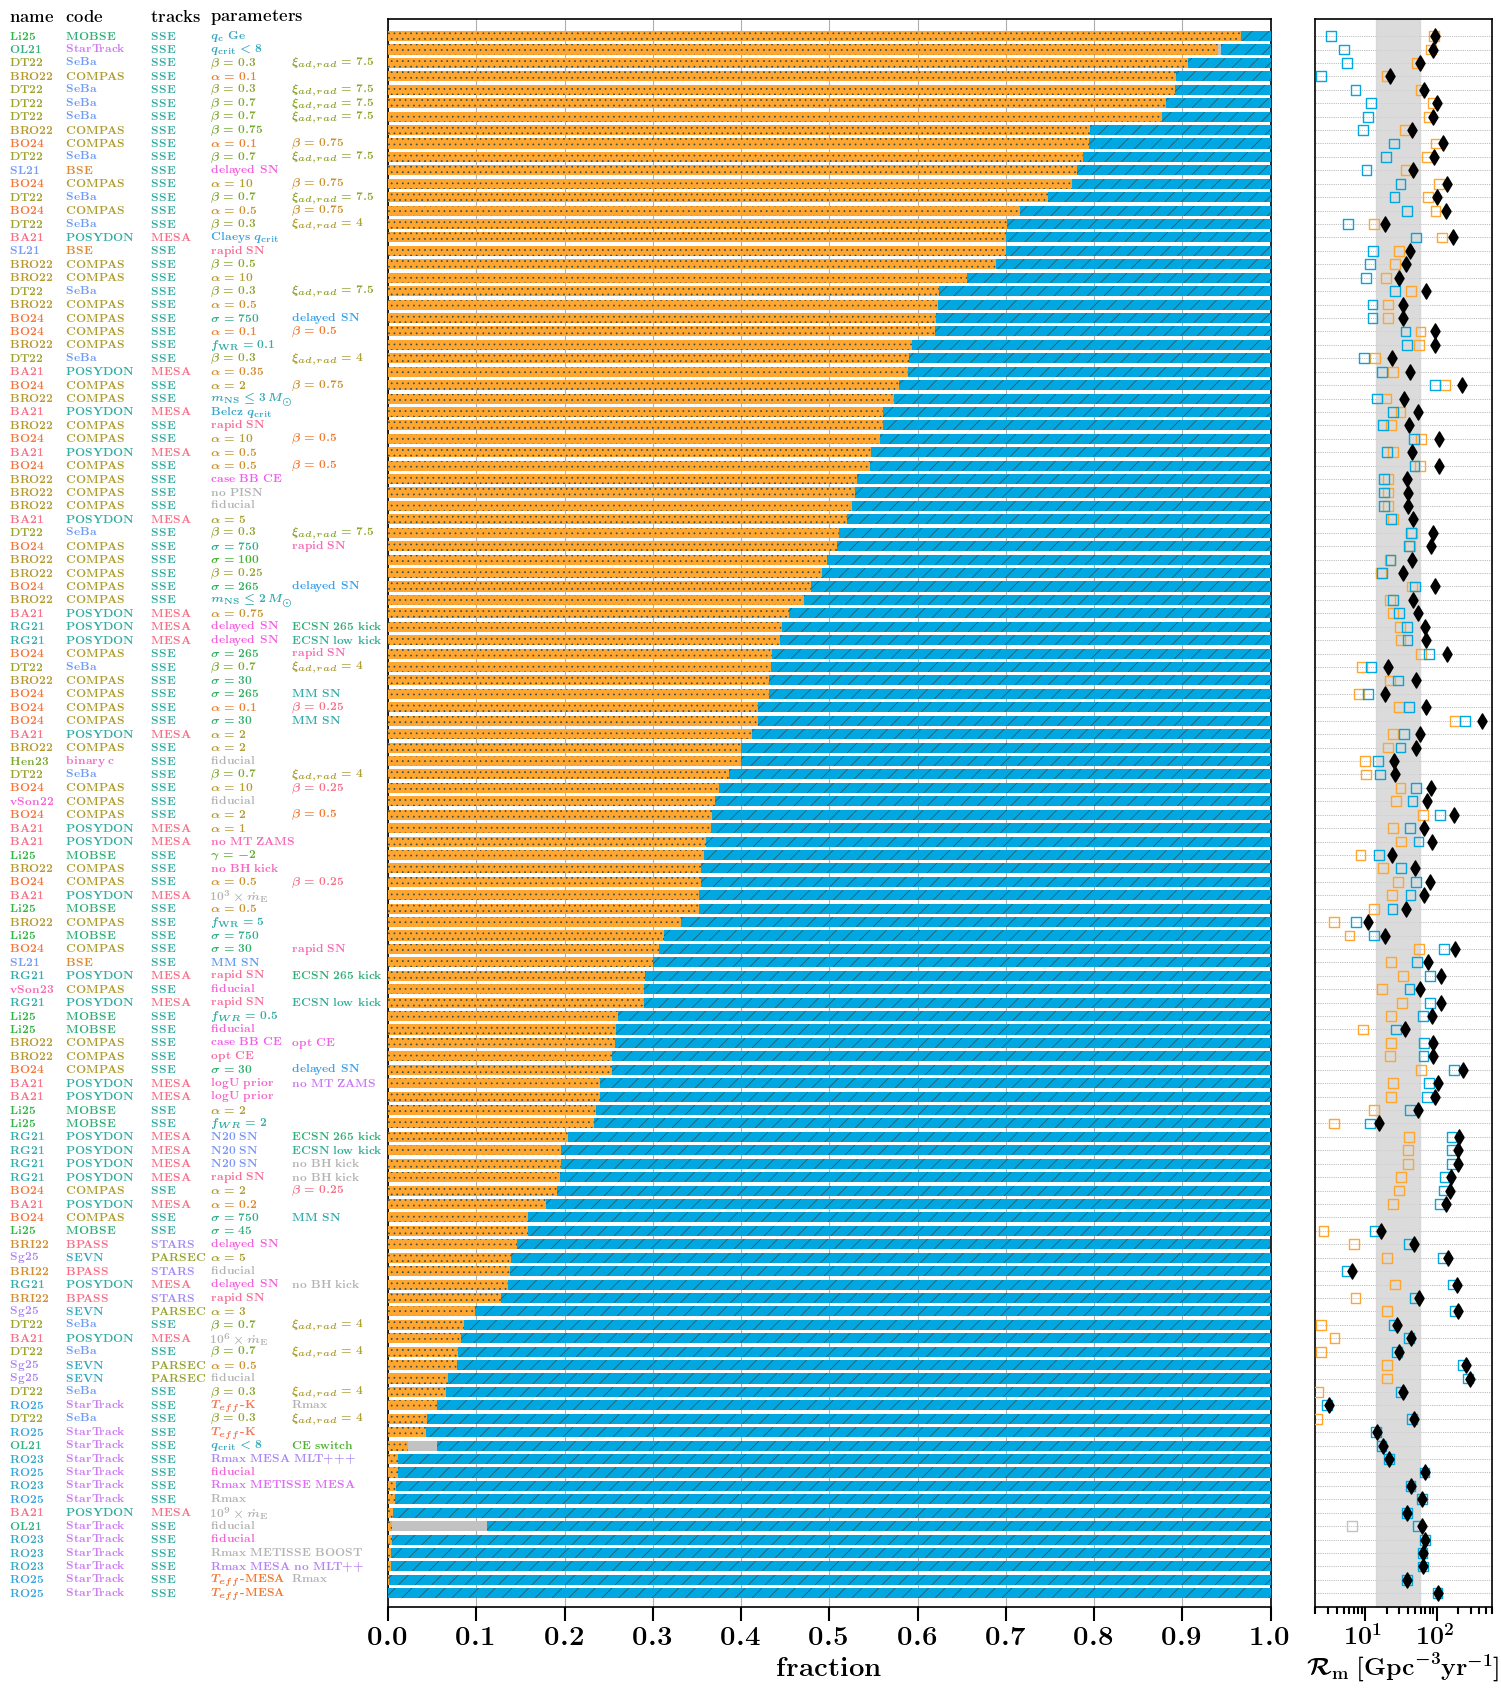

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


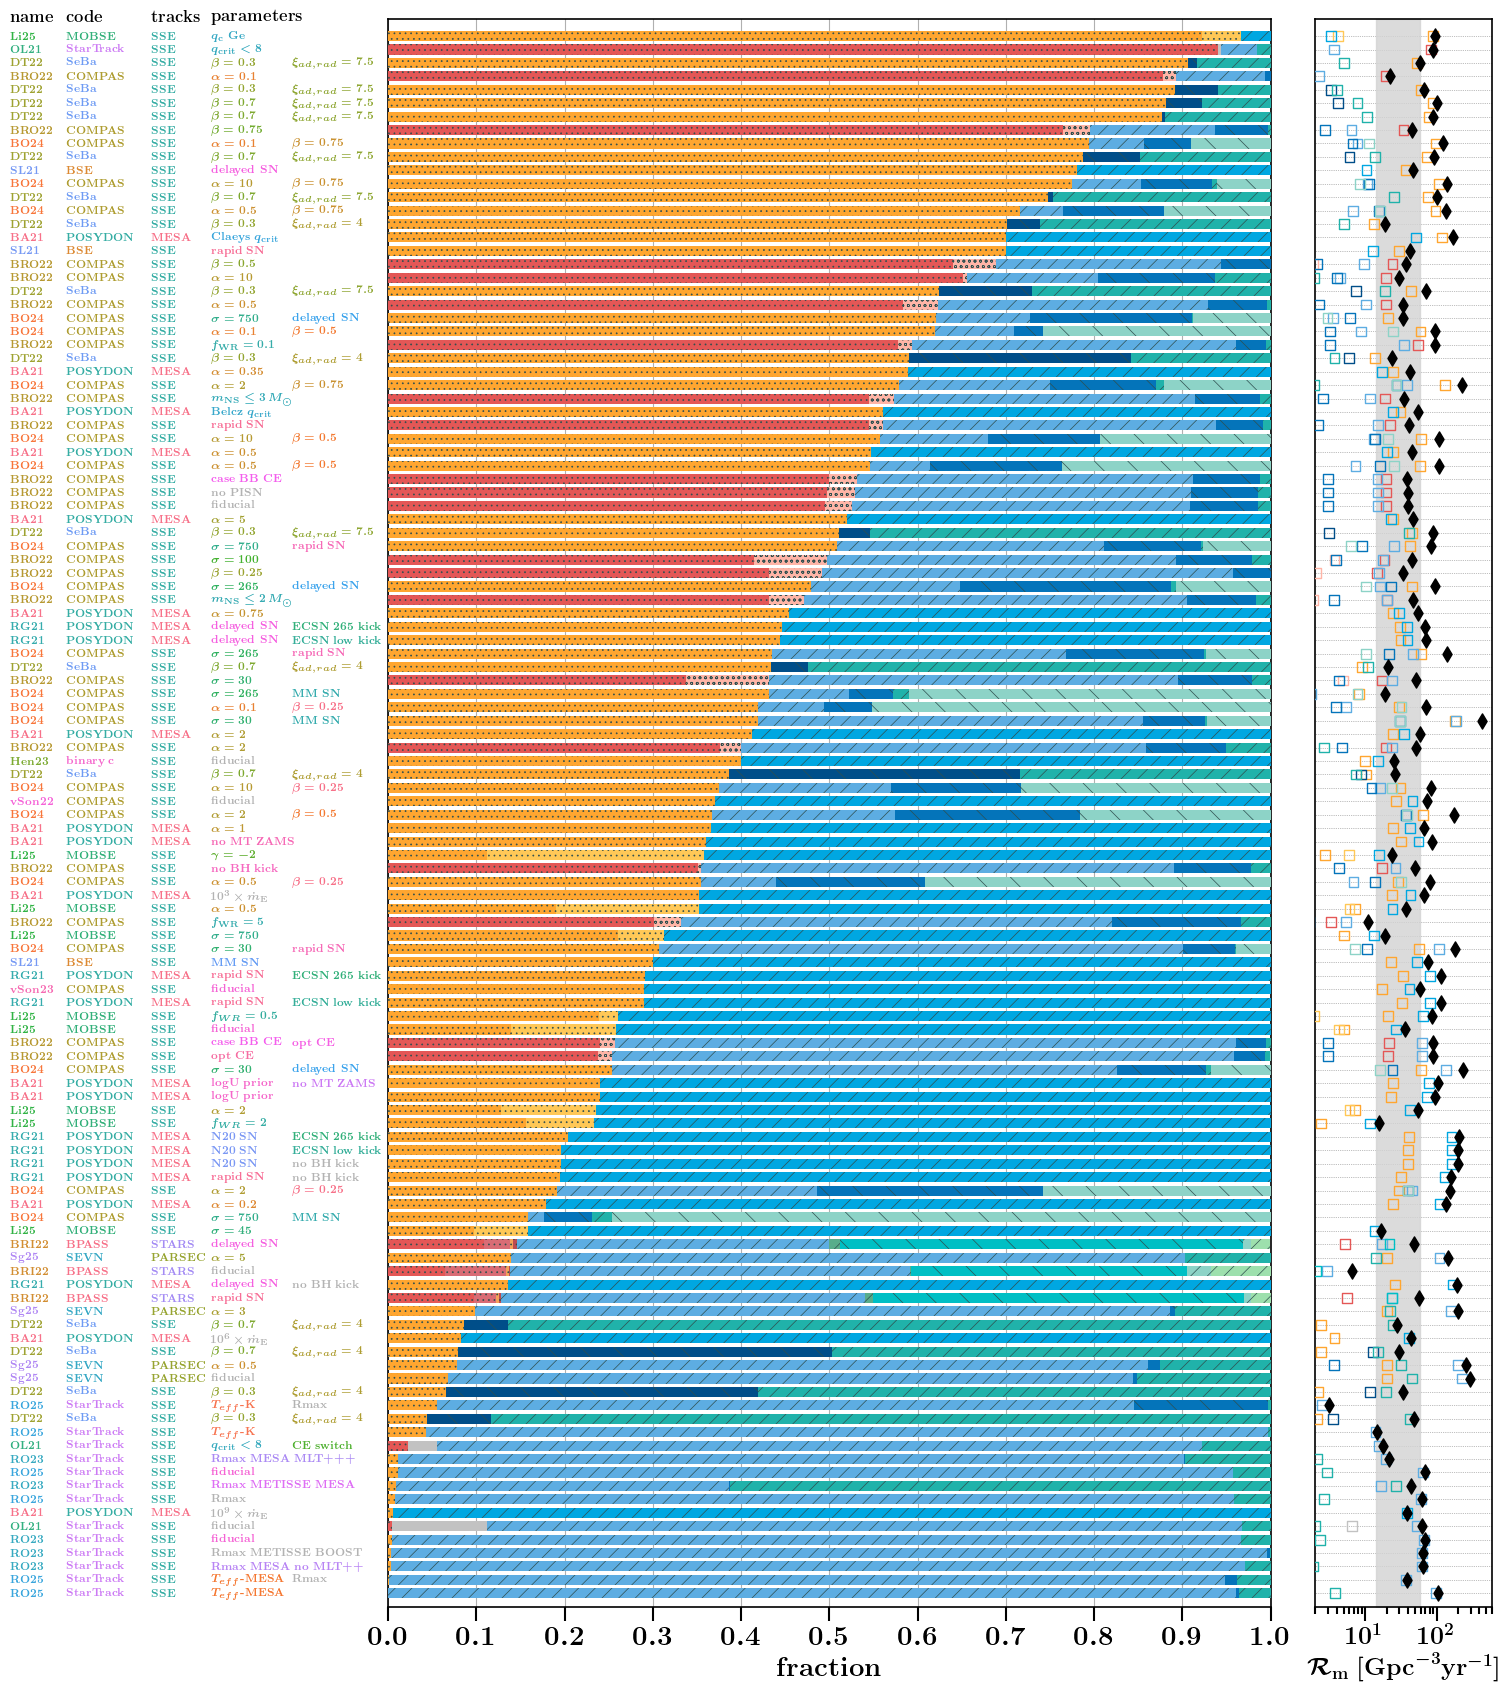

(<Figure size 1500x1700 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [4]:



# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_BH-BH_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_BH-BH_detailed.pdf"
    )




# BH-NS mergers

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


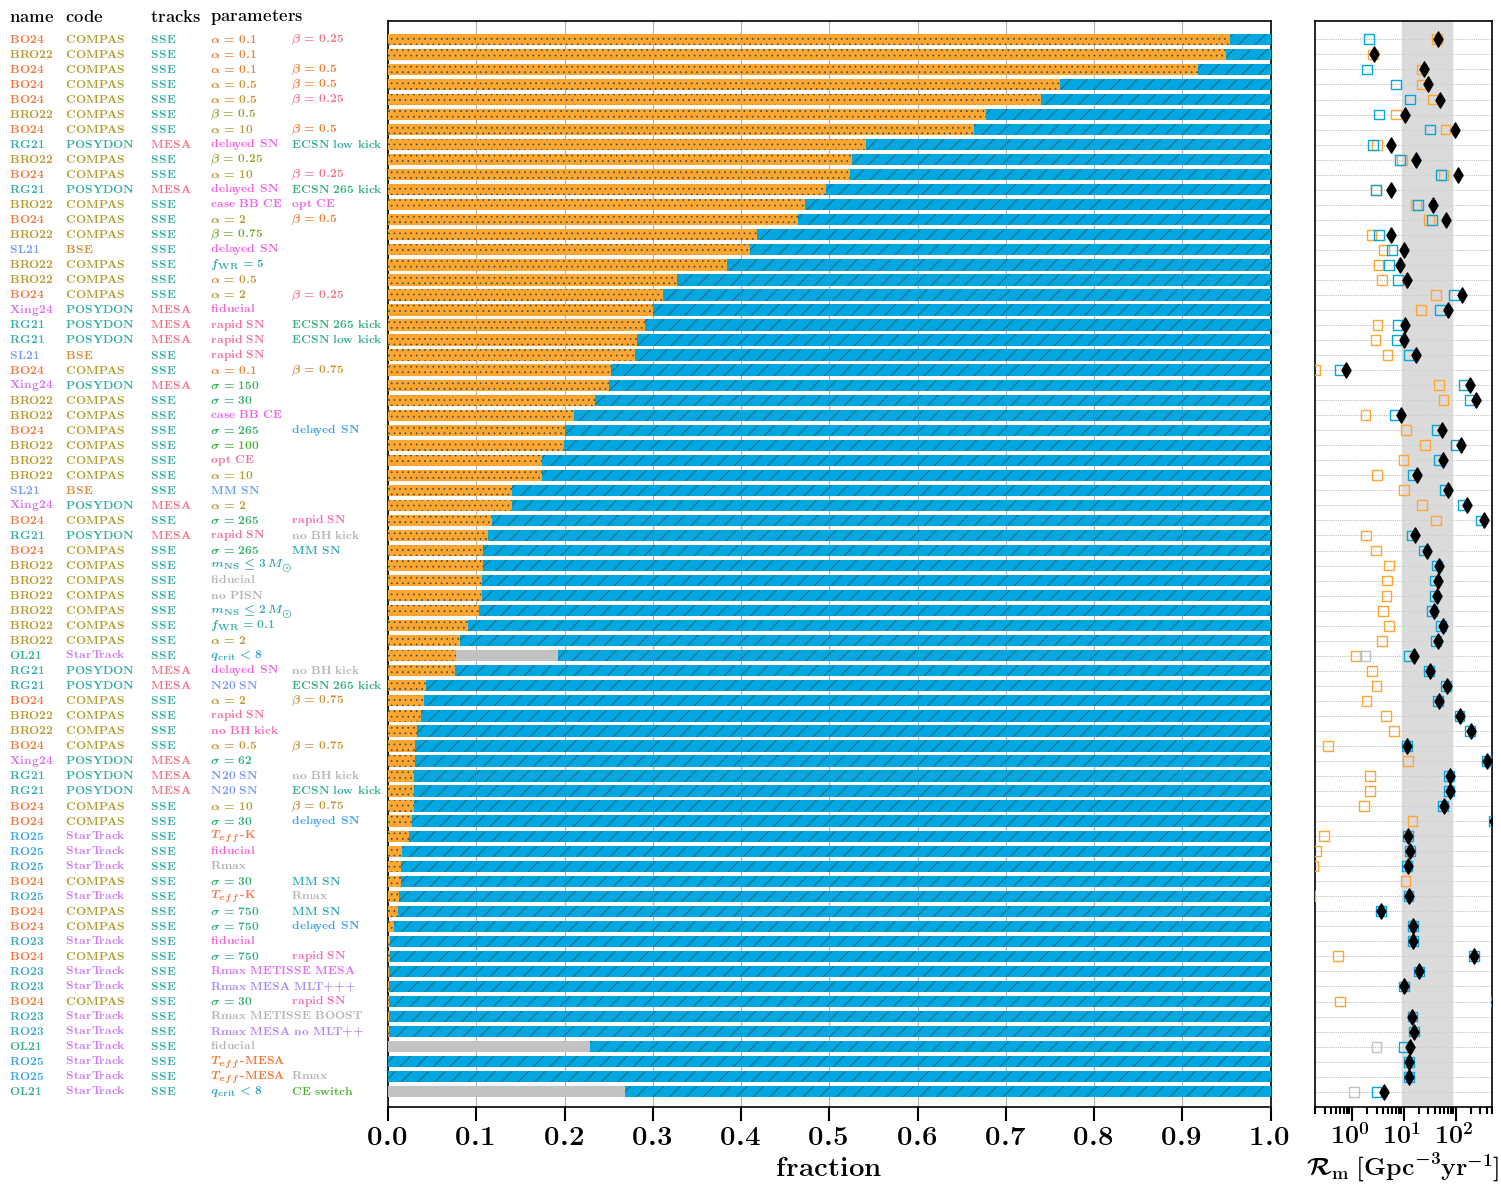

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


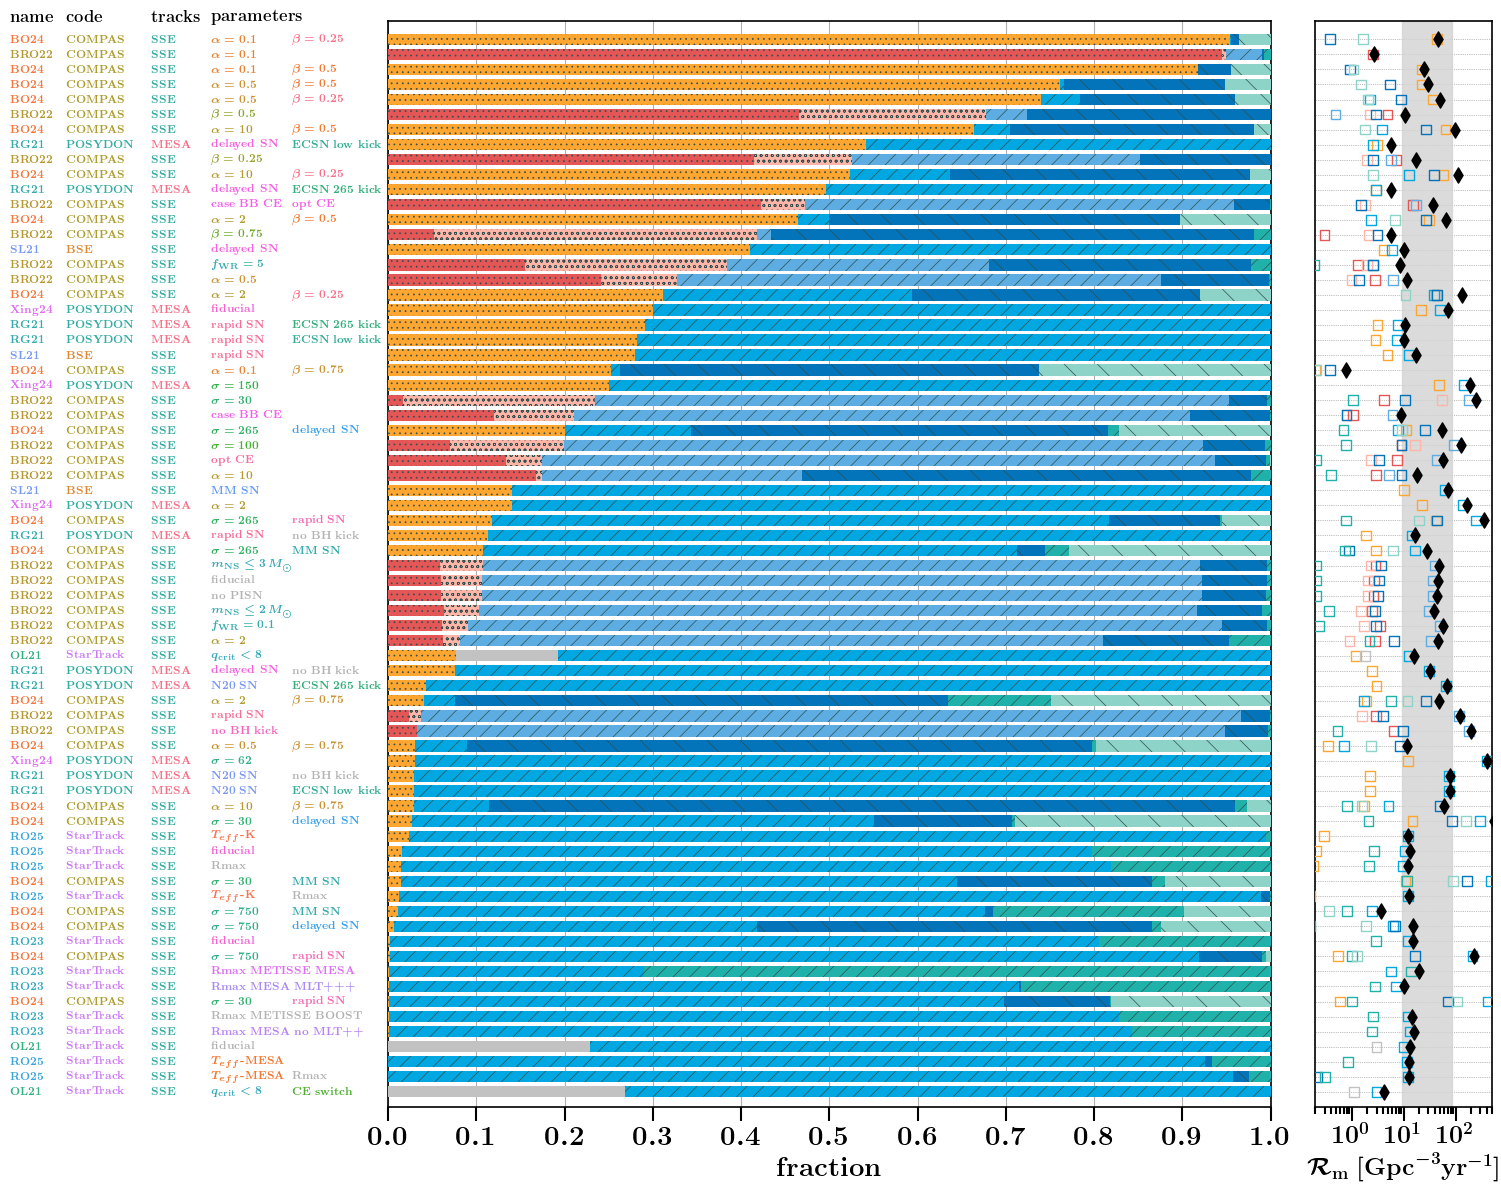

(<Figure size 1500x1200 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [5]:



# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-NS',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_BH-NS_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-NS',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_BH-NS_detailed.pdf"
    )


# NS-NS mergers 

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


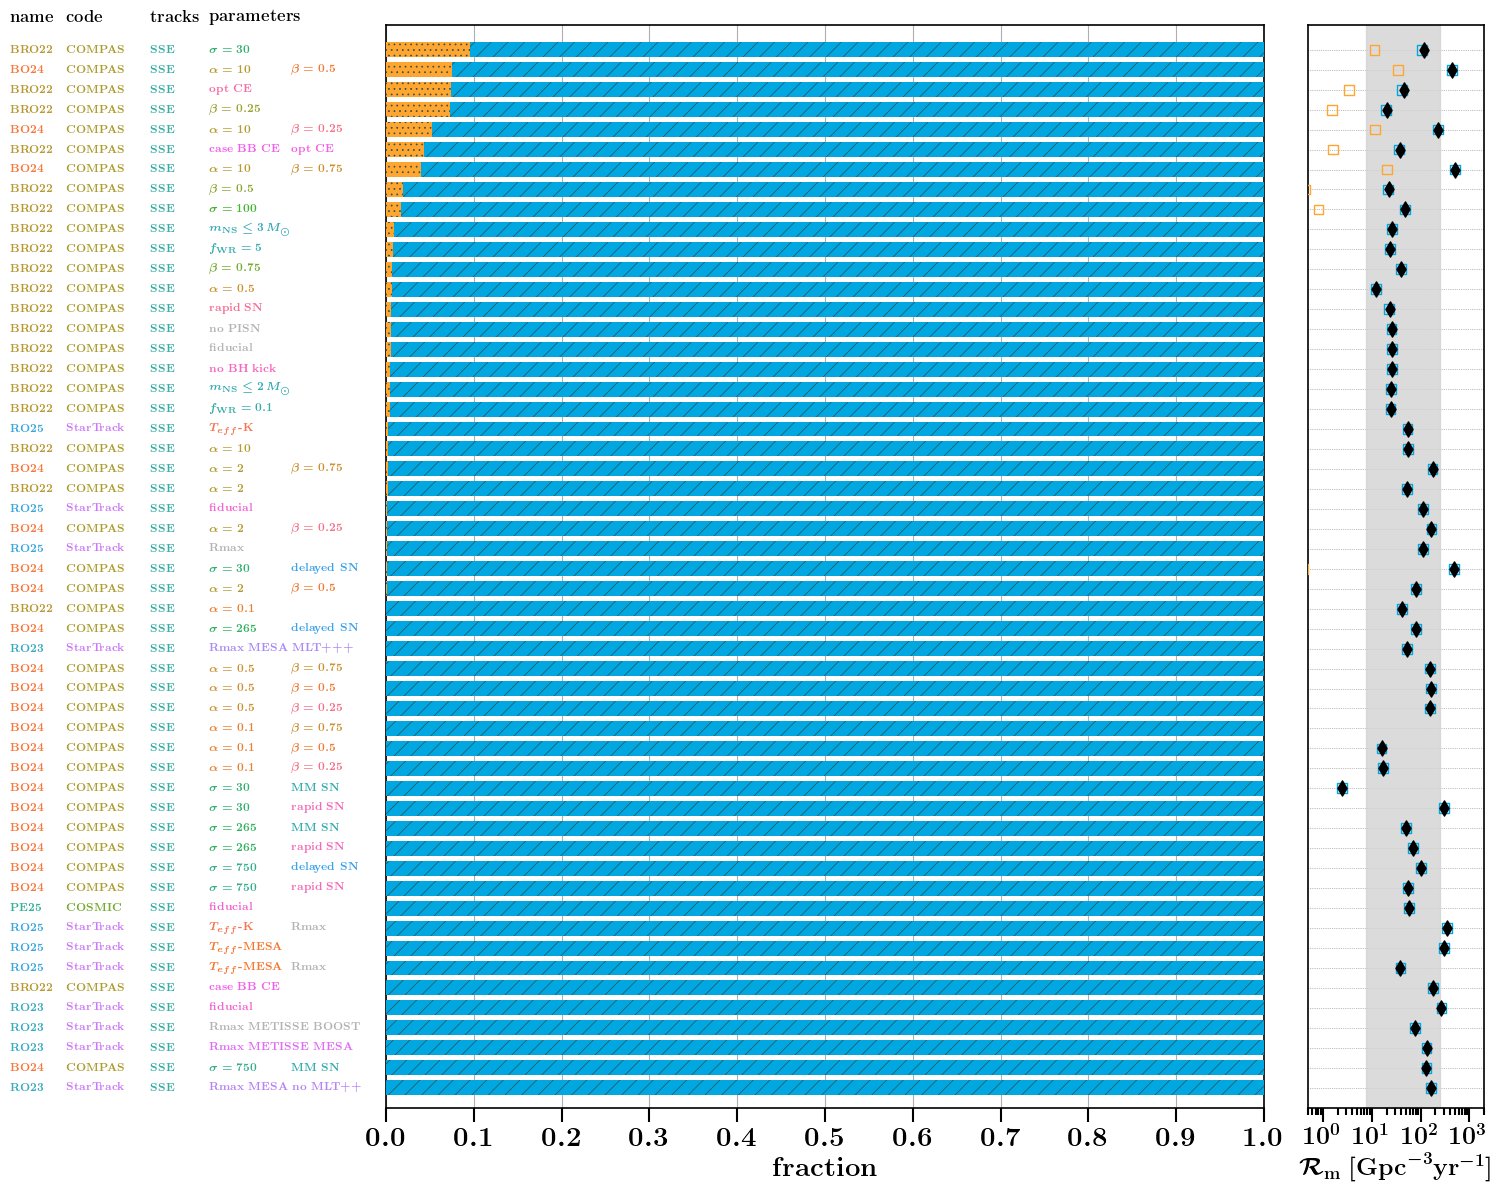

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


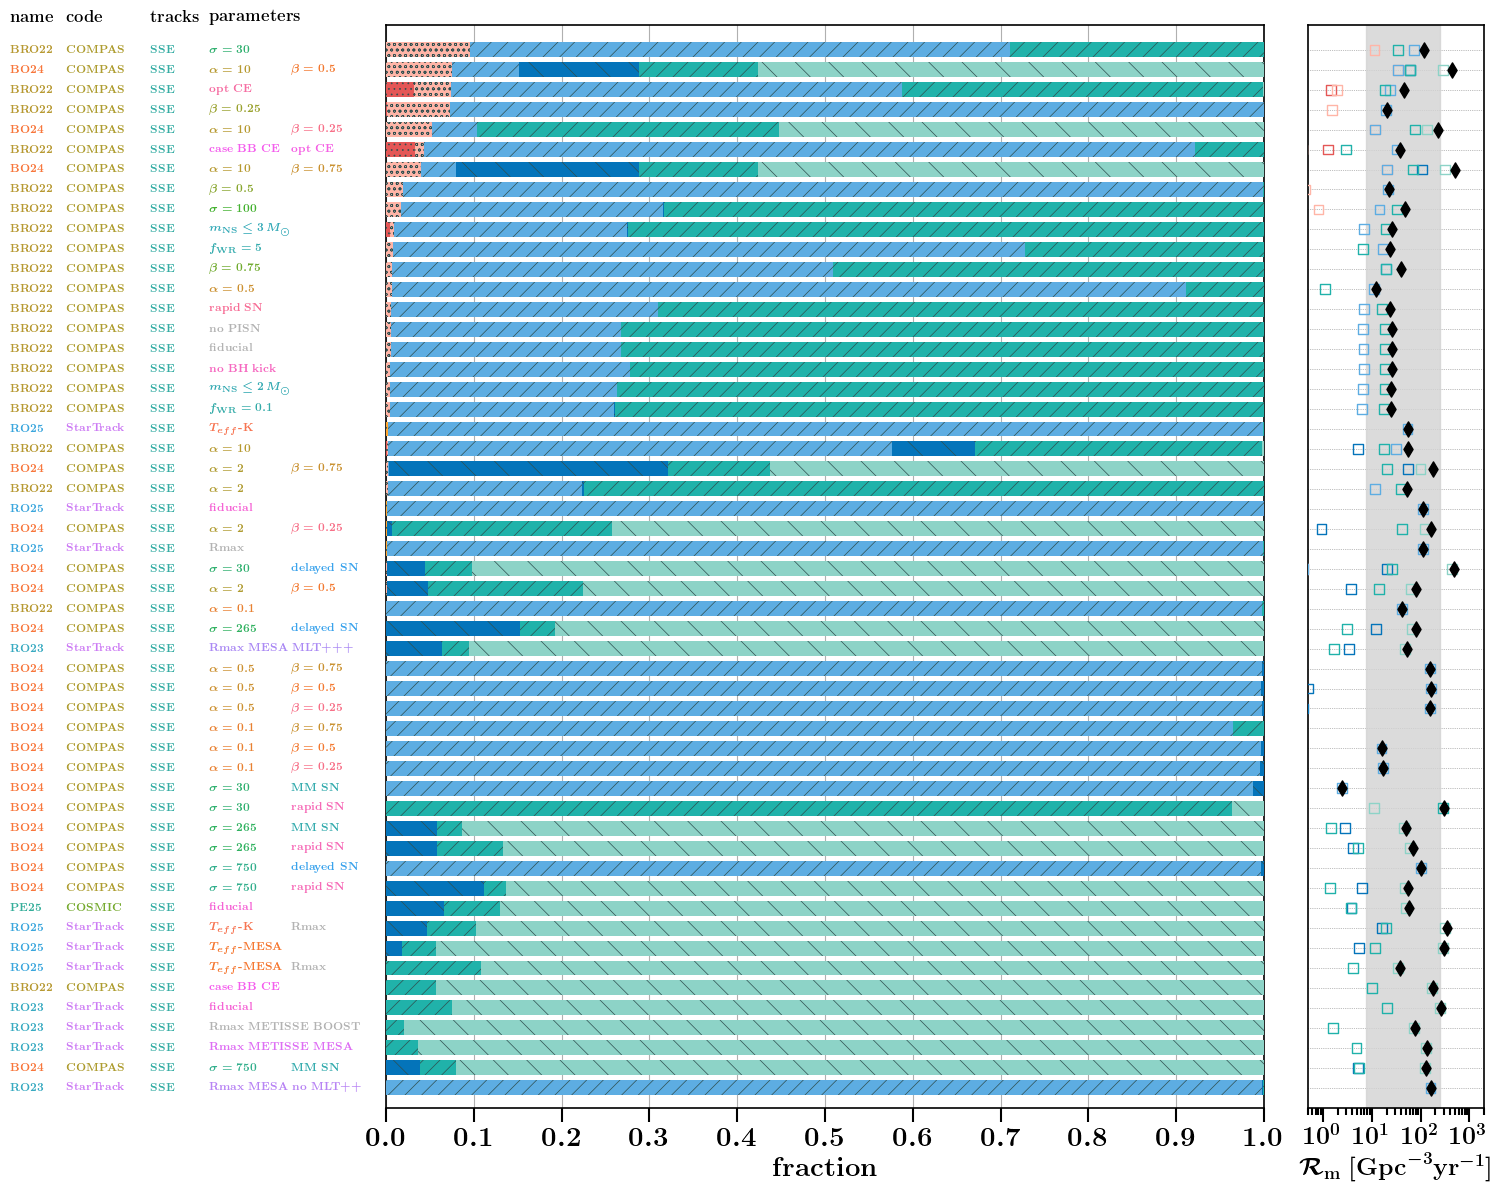

(<Figure size 1500x1200 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [6]:


# ---  plot setup ---

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'NS-NS',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_NS-NS_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'NS-NS',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_NS-NS_detailed.pdf"
    )


# Simulation Properties 


path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/Data_formation_channels_intrinsic/simulation_specs.csv


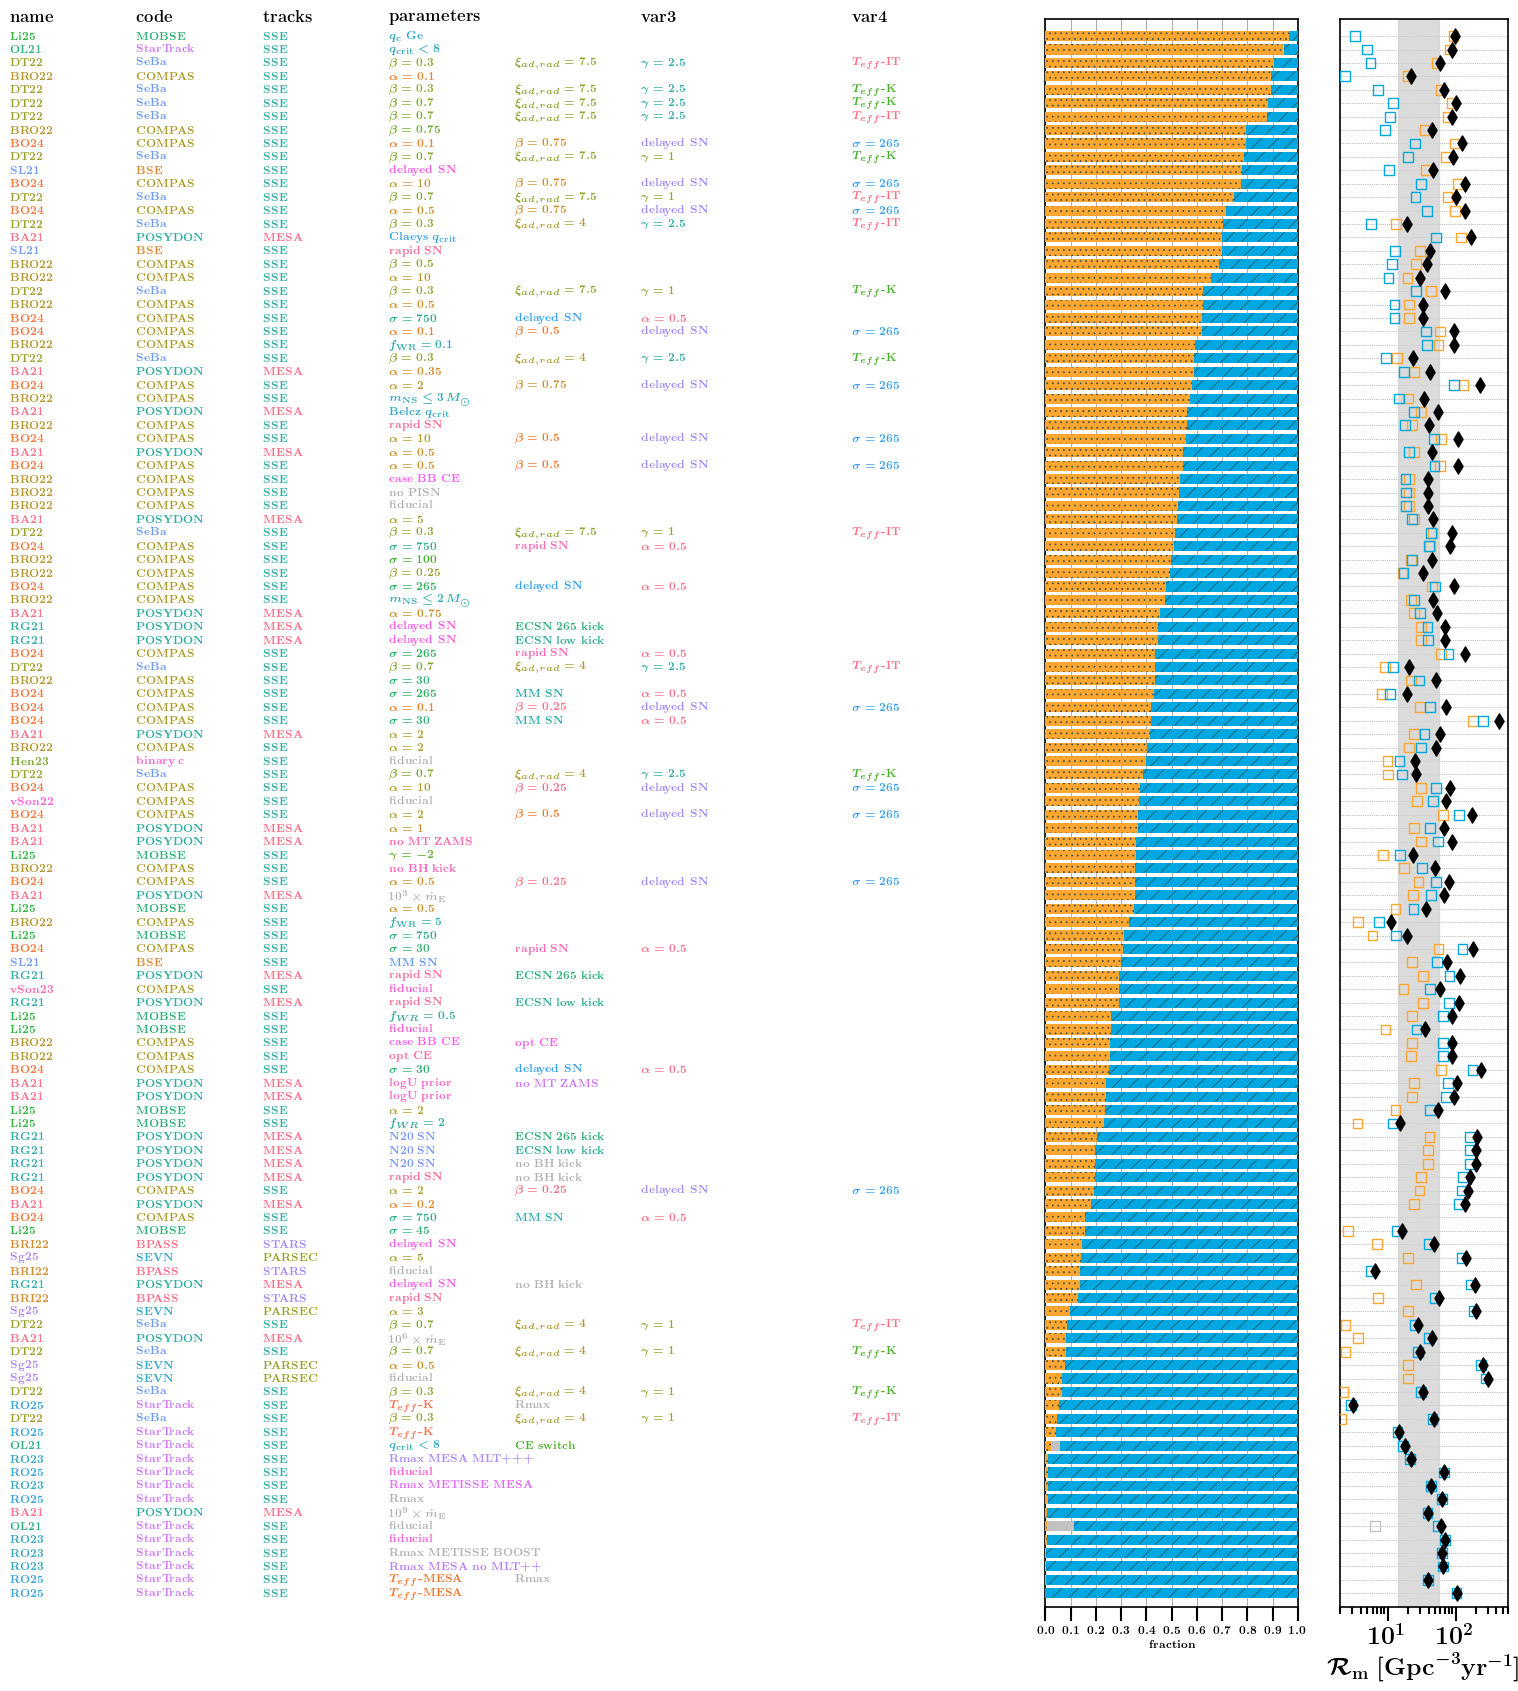

In [7]:


# --- File and plot setup ---

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "Output_Figures/Fig3_formation_channels_BH-BH_simple_specs.pdf",
    fig_formtype='emph_specs'
    )


# # plot detailed formation channels CE 
# plot_formation_channel_contributions(
#     path_to_file=path_to_file,
#     DCOlabel = 'BH-BH',
#     fc_key = "CE_detailed" ,
#     sort_header = "fraction without common envelope",
#     save_path = "formation_channels_BH-NS_detailed_specs.pdf"
#     )




In [8]:
# plot the legend 



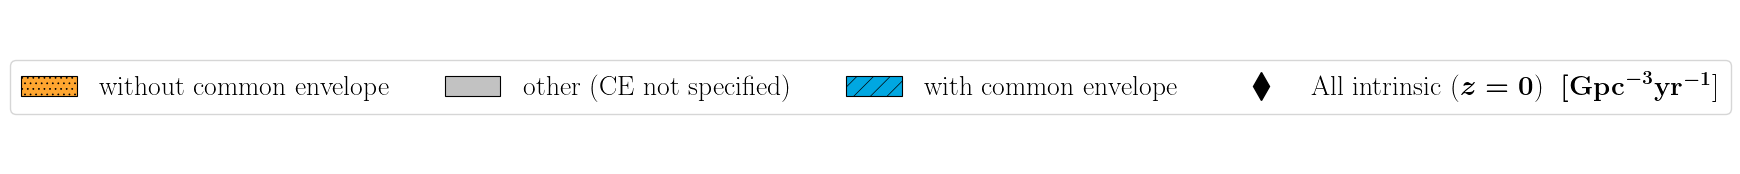

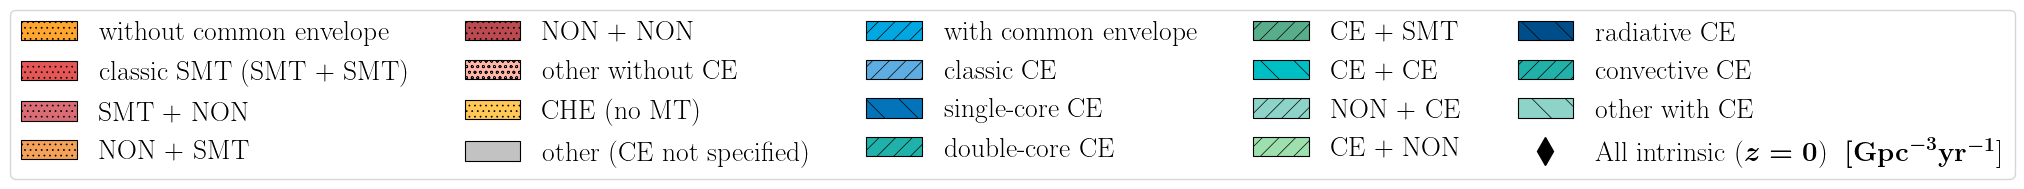

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib as mpl

def plot_fc_legend(fc_key="CE_simple", include_total=True):
    """
    Create a plot legend for the specified formation channel group.
    
    Parameters
    ----------
    fc_key : str
        Key in fc_dict (e.g., "CE_simple" or "CE_detailed").
    include_total : bool
        If True, add the 'total' diamond marker to the legend.
    """
    mpl.rcParams["text.usetex"] = True
    
    fc_dict = obtain_fc_dict()
    
    if fc_key not in fc_dict:
        raise ValueError(f"fc_key '{fc_key}' not found in fc_dict. "
                         f"Available keys: {list(fc_dict.keys())}")
    
    group = fc_dict[fc_key]
    handles, labels = [], []
    
    # Add bar patches for channels
    if "channels" in group:  
        for ch in group["channels"]:
            patch = mpatches.Patch(
                facecolor=ch["color"], 
                hatch=ch["hatch"] if ch["hatch"] else "",
                edgecolor="black",
                linewidth=0.8
            )
            handles.append(patch)
            labels.append(ch.get("label", ch["name"]))
    else:  
        # single entry (unlikely for CE_simple/detailed but valid for total-only plots)
        ch = group
        patch = mpatches.Patch(
            facecolor=ch["color"], 
            hatch=ch["hatch"] if ch["hatch"] else "",
            edgecolor="black",
            linewidth=0.8
        )
        handles.append(patch)
        labels.append(ch.get("label", ch["name"]))
    
    # Add the total marker if requested
    if include_total:
        total_ch = fc_dict["total"]
        total_marker = Line2D(
            [0], [0],
            marker="d", color=total_ch["color"], markersize=14,
            linestyle="None", markeredgecolor="black"
        )
        handles.append(total_marker)
        labels.append(total_ch.get("label", total_ch["name"]))
    
    # Dummy plot for legend only
    fig, ax = plt.subplots(figsize=(7, 2))
    ax.axis("off")
    legend = ax.legend(handles, labels, loc="center", frameon=True, ncol=5, fontsize=20)
    save_path= 'Output_Figures/Fig3_' + fc_key + '_lgd.pdf'
    fig.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()
    
    
plot_fc_legend("CE_simple")
plot_fc_legend("CE_detailed")
# plot_fc_legend("total")


## Create a zip file folder that contains the PNG images to create the large legend for the powerpoint overview of formationchannels


In [10]:
import os
import re
from collections import defaultdict

import matplotlib as mpl
mpl.use("Agg")  # headless / no GUI

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def sanitize_filename(text: str, max_len: int = 140) -> str:
    text = text.strip()
    text = re.sub(r"\s+", "_", text)
    text = text.replace("\\", "")  # avoid awkward filenames
    text = text.replace("{", "").replace("}", "")
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    text = text.strip("._-")
    return (text or "label")[:max_len]


def save_patch_png(
    color: str,
    hatch, #hatch: str | None,
    outpath: str,
    *,
    width_px: int = 420,
    height_px: int = 120,
    dpi: int = 200,
    edgecolor: str = "black",
    linewidth: float = 0.8,
    hatch_color: str = "darkslategray",
    hatch_linewidth: float = 0.6,
    transparent_bg: bool = True,
    pad_fraction: float = 0.12,
):
    """
    Render a single Matplotlib Patch (with hatch) to a PNG, tightly cropped.
    """
    # Hatch tuning (matches your style intent)
    mpl.rcParams["hatch.linewidth"] = hatch_linewidth
    mpl.rcParams["hatch.color"] = hatch_color

    # Compute a figure size that roughly matches your requested pixels
    fig_w = width_px / dpi
    fig_h = height_px / dpi

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    pad = pad_fraction
    rect = mpatches.Rectangle(
        (pad, pad),
        1 - 2 * pad,
        1 - 2 * pad,
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        hatch=(hatch if hatch else ""),
    )
    ax.add_patch(rect)

    fig.savefig(
        outpath,
        format="png",
        dpi=dpi,
        transparent=transparent_bg,
        bbox_inches="tight",
        pad_inches=0.0,
    )
    plt.close(fig)


def export_channel_patches_as_pngs(
    fc_dict: dict,
    out_dir: str = "legend_color_bars_mpl",
    *,
    width_px: int = 420,
    height_px: int = 120,
    dpi: int = 200,
    transparent_bg: bool = True,
):
    """
    Writes one PNG per unique (label, color, hatch). If a label maps to multiple styles,
    filenames get suffixes _01, _02, etc.
    """
    os.makedirs(out_dir, exist_ok=True)

    # label -> set of (color, hatch)
    label_to_styles = defaultdict(set)

    for group in fc_dict.values():
        if isinstance(group, dict) and "channels" in group:
            for ch in group["channels"]:
                label = ch.get("label")
                color = ch.get("color")
                hatch = ch.get("hatch")
                if label and color:
                    label_to_styles[label].add((color, hatch))
        elif isinstance(group, dict):
            # e.g. total; you can include/exclude as you wish
            label = group.get("label")
            color = group.get("color")
            hatch = group.get("hatch")
            if label and color:
                label_to_styles[label].add((color, hatch))

    n_written = 0
    for label, styles in sorted(label_to_styles.items(), key=lambda x: x[0].lower()):
        base = sanitize_filename(label)
        styles = sorted(styles)

        if len(styles) == 1:
            color, hatch = styles[0]
            outpath = os.path.join(out_dir, f"{base}.png")
            save_patch_png(
                color, hatch, outpath,
                width_px=width_px, height_px=height_px, dpi=dpi,
                transparent_bg=transparent_bg,
            )
            n_written += 1
        else:
            for i, (color, hatch) in enumerate(styles, start=1):
                outpath = os.path.join(out_dir, f"{base}_{i:02d}.png")
                save_patch_png(
                    color, hatch, outpath,
                    width_px=width_px, height_px=height_px, dpi=dpi,
                    transparent_bg=transparent_bg,
                )
                n_written += 1

    print(f"Wrote {n_written} PNG(s) to: {os.path.abspath(out_dir)}")


# -----------------------
# Usage
# -----------------------
fc_dict = obtain_fc_dict()
export_channel_patches_as_pngs(fc_dict, out_dir="legend_color_bars_mpl", transparent_bg=True)


Wrote 20 PNG(s) to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/All_Figures/legend_color_bars_mpl
